# Sketch-to-Photo Retrieval: Benchmarking Embedding Architectures with Vector Search
---


This notebook implements a cross-domain similarity search system that retrieves the nearest-neighbour **photographs** from a corpus given a raw **hand-drawn sketch** as the query. The search is purely vector-based — no text, labels, or metadata are used at any point in the retrieval pipeline.

Two embedding architectures are benchmarked end-to-end:

| Component | Design Choice | Rationale |
|:---|:---|:---|
| **Modality** | Image — sketch → photo (cross-domain) | Tests embedding robustness across a visual domain gap |
| **Dataset** | Sketchy Database — 125 categories, ~12,500 photos, ~75,000 sketches | Rich paired data for rigorous cross-domain recall evaluation |
| **Embedding A** | ResNet-50 (ImageNet, 2048-dim) | Baseline: strong photo features, no cross-domain pre-training |
| **Embedding B** | CLIP ViT-B/32 (512-dim) | Hypothesis: contrastive pre-training bridges the sketch–photo domain gap |
| **Vector DB** | Qdrant — HNSW index, cosine similarity | Production-grade ANN search with tunable indexing parameters |
| **Evaluation** | Recall@K (K=1,5,10,20), MRR, query latency | Quantitative metrics + visual cluster analysis (t-SNE / PCA) |

---
## 1. Environment Setup & Global Configuration

In [1]:
# ── Standard library ────────────────────────────────────────────────────────
import warnings, time, random
from pathlib import Path
from collections import defaultdict
from importlib.metadata import version as pkg_ver

# ── Numerics & data ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

# ── Deep learning ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as T
from torchvision.models import ResNet50_Weights
import open_clip

# ── Vector database ─────────────────────────────────────────────────────────
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct, HnswConfigDiff, SearchParams
)

# ── Dimensionality reduction & metrics ──────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

# ── Global settings ─────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
RANDOM_STATE  = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE    = 64
TOP_K_VALUES  = [1, 5, 10, 20]
VIZ_CATS      = 20
SKETCHES_PER_CAT_EVAL = 10

# Dataset paths
DATA_ROOT    = Path("rendered_256x256/256x256")
PHOTO_SPLIT  = "tx_000000000000"
SKETCH_SPLIT = "tx_000000000000"
PHOTO_DIR    = DATA_ROOT / "photo"  / PHOTO_SPLIT
SKETCH_DIR   = DATA_ROOT / "sketch" / SKETCH_SPLIT

# Output directories
FIGS_DIR = Path("figs");       FIGS_DIR.mkdir(exist_ok=True)
EMB_DIR  = Path("embeddings"); EMB_DIR.mkdir(exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = sns.color_palette("tab20", VIZ_CATS)

print(f"Device       : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"torch        : {torch.__version__}")
print(f"open_clip    : {open_clip.__version__}")
print(f"qdrant       : {pkg_ver('qdrant-client')}")
print(f"Photo dir    : {PHOTO_DIR.exists()}")
print(f"Sketch dir   : {SKETCH_DIR.exists()}")

Device       : cuda
GPU          : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM         : 6.4 GB
torch        : 2.5.1+cu121
open_clip    : 3.3.0
qdrant       : 1.19.0
Photo dir    : True
Sketch dir   : True


---
## 2. Data Pipeline — Sketchy Database

The **Sketchy Database** (Liu et al., 2017) is a dataset containing 75,471 hand-drawn sketches and 12,500 photographs spanning 125 object categories. Images are pre-rendered at 256×256 pixels.


In [2]:
def load_image_paths(base_dir: Path) -> dict:
    """Return {category: [image_paths]} for all categories under base_dir."""
    return {
        cat.name: sorted(cat.iterdir())
        for cat in sorted(base_dir.iterdir())
        if cat.is_dir()
    }


def build_dataframe(paths_dict: dict, modality: str) -> pd.DataFrame:
    """Flatten {category: [paths]} into a tidy DataFrame."""
    rows = [
        {"path": str(p), "category": cat, "modality": modality}
        for cat, paths in paths_dict.items()
        for p in paths
    ]
    return pd.DataFrame(rows)


# Load paths
photo_paths  = load_image_paths(PHOTO_DIR)
sketch_paths = load_image_paths(SKETCH_DIR)
CATEGORIES   = sorted(photo_paths.keys())

photo_df  = build_dataframe(photo_paths,  "photo")
sketch_df = build_dataframe(sketch_paths, "sketch")

# Stratified evaluation query set (10 sketches / category)
eval_rows = []
for cat in CATEGORIES:
    pool = sketch_df[sketch_df["category"] == cat]
    n    = min(SKETCHES_PER_CAT_EVAL, len(pool))
    eval_rows.append(pool.sample(n=n, random_state=RANDOM_STATE))
eval_sketch_df = pd.concat(eval_rows, ignore_index=True)

# Dataset summary
summary = pd.DataFrame({
    "Split"          : ["Photo corpus (retrieval DB)", "Sketch full set", "Sketch eval queries"],
    "Images"         : [len(photo_df), len(sketch_df), len(eval_sketch_df)],
    "Categories"     : [photo_df["category"].nunique(),
                        sketch_df["category"].nunique(),
                        eval_sketch_df["category"].nunique()],
    "Avg / category" : [
        f"{len(photo_df)  / photo_df['category'].nunique():.0f}",
        f"{len(sketch_df) / sketch_df['category'].nunique():.0f}",
        f"{len(eval_sketch_df) / eval_sketch_df['category'].nunique():.0f}",
    ]
})
print(summary.to_string(index=False))

                      Split  Images  Categories Avg / category
Photo corpus (retrieval DB)   12500         125            100
            Sketch full set   75481         125            604
        Sketch eval queries    1250         125             10


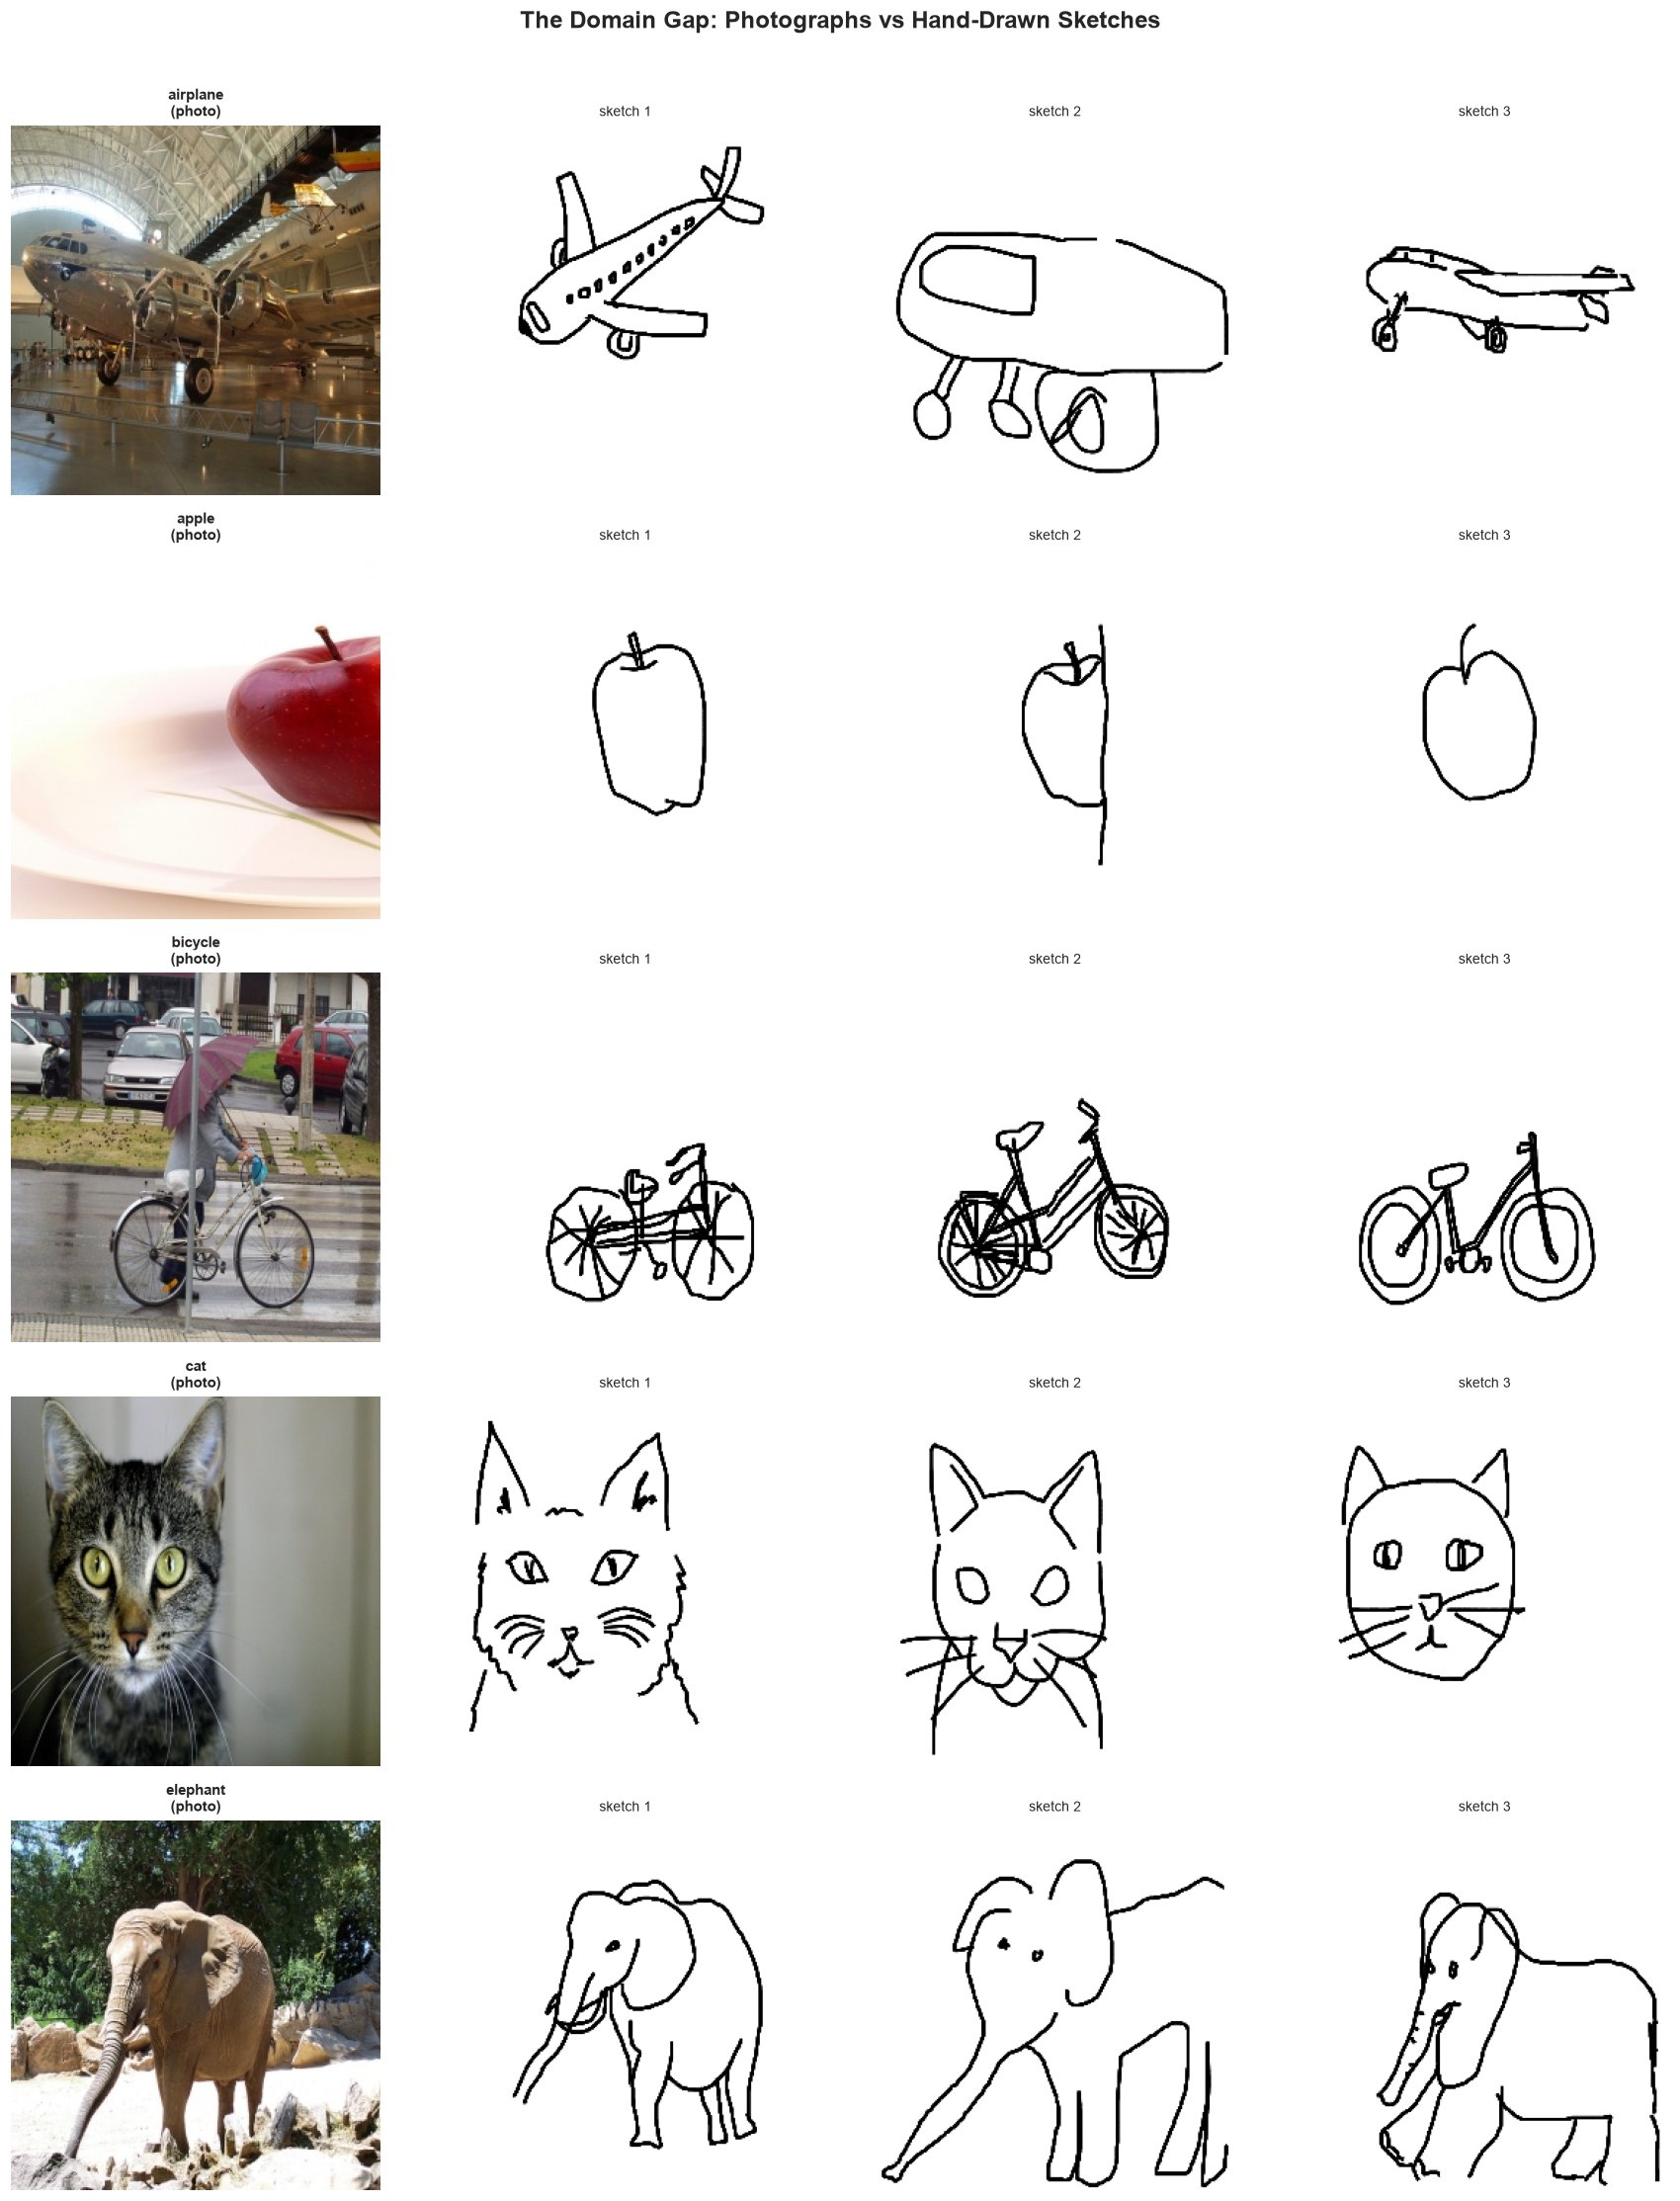

Saved → figs/00_domain_gap_samples.png


In [3]:
# Sample grid: illustrating the domain gap
SAMPLE_CATS  = ["airplane", "apple", "bicycle", "cat", "elephant"]
SKETCHES_PER = 3

fig, axes = plt.subplots(
    len(SAMPLE_CATS), 1 + SKETCHES_PER,
    figsize=(4 * (1 + SKETCHES_PER), 4 * len(SAMPLE_CATS))
)
fig.suptitle("The Domain Gap: Photographs vs Hand-Drawn Sketches",
             fontsize=16, fontweight="bold", y=1.01)

for row_i, cat in enumerate(SAMPLE_CATS):
    photo_p = photo_paths[cat][0]
    axes[row_i, 0].imshow(Image.open(photo_p))
    axes[row_i, 0].set_title(f"{cat}\n(photo)", fontsize=10, fontweight="bold")
    axes[row_i, 0].axis("off")
    for spine in axes[row_i, 0].spines.values():
        spine.set_edgecolor("#2ecc71"); spine.set_linewidth(3)

    for col_i, sketch_p in enumerate(sketch_paths[cat][:SKETCHES_PER]):
        axes[row_i, col_i + 1].imshow(Image.open(sketch_p), cmap="gray")
        axes[row_i, col_i + 1].set_title(f"sketch {col_i+1}", fontsize=9)
        axes[row_i, col_i + 1].axis("off")

plt.tight_layout()
plt.savefig(FIGS_DIR / "00_domain_gap_samples.png", bbox_inches="tight")
plt.show()
print("Saved → figs/00_domain_gap_samples.png")

Photographs carry rich texture, colour, lighting, and depth cues. 

Sketches are sparse, monochromatic, and abstract

---
## 3. Embedding Model A — ResNet-50 (ImageNet Pretrained)
This vector captures rich photographic features (texture, colour histograms, spatial patterns) but was never exposed to sketch data during training.

In [4]:
def build_resnet():
    """Load ResNet-50, remove the classification head, return (model, transform)."""
    backbone  = tv_models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    extractor = nn.Sequential(*list(backbone.children())[:-1])  # up to avgpool → 2048-dim
    extractor.eval().to(DEVICE)

    transform = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std= [0.229, 0.224, 0.225]),
    ])
    return extractor, transform


resnet_model, resnet_transform = build_resnet()
total_params = sum(p.numel() for p in resnet_model.parameters()) / 1e6
print(f"ResNet-50 | Parameters: {total_params:.1f}M | Output dim: 2048 | Device: {DEVICE}")

ResNet-50 | Parameters: 23.5M | Output dim: 2048 | Device: cuda


In [5]:
def embed_images(image_paths, model, transform, batch_size=BATCH_SIZE, desc="Embedding"):
    """
    Embed a list of image paths in batches.
    Returns an L2-normalised float32 array of shape (N, D).
    """
    all_vecs = []
    model.eval()

    for start in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[start : start + batch_size]
        imgs = [transform(Image.open(p).convert("RGB")) for p in batch_paths]
        batch = torch.stack(imgs).to(DEVICE)

        with torch.no_grad():
            vecs = model(batch).squeeze(-1).squeeze(-1)   # (B, D)
        all_vecs.append(vecs.cpu().float().numpy())

    embeddings = np.vstack(all_vecs)
    return normalize(embeddings, norm="l2")


# Generate (or load cached) ResNet embeddings
RN_PHOTO_PATH  = EMB_DIR / "photo_resnet.npy"
RN_SKETCH_PATH = EMB_DIR / "sketch_resnet.npy"

if RN_PHOTO_PATH.exists() and RN_SKETCH_PATH.exists():
    print("Loading cached ResNet embeddings...")
    photo_emb_resnet  = np.load(RN_PHOTO_PATH)
    sketch_emb_resnet = np.load(RN_SKETCH_PATH)
else:
    t0 = time.time()
    photo_emb_resnet  = embed_images(photo_df["path"].tolist(),       resnet_model, resnet_transform, desc="ResNet → Photos")
    sketch_emb_resnet = embed_images(eval_sketch_df["path"].tolist(), resnet_model, resnet_transform, desc="ResNet → Sketches")
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.1f}s ({(len(photo_df)+len(eval_sketch_df))/elapsed:.0f} img/s)")
    np.save(RN_PHOTO_PATH,  photo_emb_resnet)
    np.save(RN_SKETCH_PATH, sketch_emb_resnet)

print(f"photo_emb_resnet  : {photo_emb_resnet.shape}  | norm: {np.linalg.norm(photo_emb_resnet[0]):.4f}")
print(f"sketch_emb_resnet : {sketch_emb_resnet.shape} | norm: {np.linalg.norm(sketch_emb_resnet[0]):.4f}")

Loading cached ResNet embeddings...
photo_emb_resnet  : (12500, 2048)  | norm: 1.0000
sketch_emb_resnet : (1250, 2048) | norm: 1.0000


---
## 4. Embedding Model B — CLIP ViT-B/32

CLIP (Contrastive Language-Image Pretraining): push matching image–text pairs together in embedding space and push non-matching pairs apart. Unlike ResNet, CLIP learned visual concepts from raw internet text descriptions rather than curated category labels.

In [6]:
# Build CLIP ViT-B/32
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model.eval().to(DEVICE)
total_clip = sum(p.numel() for p in clip_model.parameters()) / 1e6
print(f"CLIP ViT-B/32 | Parameters: {total_clip:.1f}M | Output dim: 512 | Device: {DEVICE}")


def embed_images_clip(image_paths, model, preprocess, batch_size=BATCH_SIZE, desc="CLIP Embedding"):
    """Embed images with CLIP's vision encoder. Returns L2-normalised (N, 512) array."""
    all_vecs = []
    model.eval()

    for start in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[start : start + batch_size]
        imgs  = [preprocess(Image.open(p).convert("RGB")) for p in batch_paths]
        batch = torch.stack(imgs).to(DEVICE)

        with torch.no_grad():
            vecs = model.encode_image(batch)   # (B, 512)
        all_vecs.append(vecs.cpu().float().numpy())

    embeddings = np.vstack(all_vecs)
    return normalize(embeddings, norm="l2")

CLIP ViT-B/32 | Parameters: 151.3M | Output dim: 512 | Device: cuda


In [7]:
# Generate (or load cached) CLIP embeddings
CL_PHOTO_PATH  = EMB_DIR / "photo_clip.npy"
CL_SKETCH_PATH = EMB_DIR / "sketch_clip.npy"

if CL_PHOTO_PATH.exists() and CL_SKETCH_PATH.exists():
    print("Loading cached CLIP embeddings...")
    photo_emb_clip  = np.load(CL_PHOTO_PATH)
    sketch_emb_clip = np.load(CL_SKETCH_PATH)
else:
    t0 = time.time()
    photo_emb_clip  = embed_images_clip(photo_df["path"].tolist(),       clip_model, clip_preprocess, desc="CLIP → Photos")
    sketch_emb_clip = embed_images_clip(eval_sketch_df["path"].tolist(), clip_model, clip_preprocess, desc="CLIP → Sketches")
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.1f}s ({(len(photo_df)+len(eval_sketch_df))/elapsed:.0f} img/s)")
    np.save(CL_PHOTO_PATH,  photo_emb_clip)
    np.save(CL_SKETCH_PATH, sketch_emb_clip)

print(f"photo_emb_clip  : {photo_emb_clip.shape}  | norm: {np.linalg.norm(photo_emb_clip[0]):.4f}")
print(f"sketch_emb_clip : {sketch_emb_clip.shape} | norm: {np.linalg.norm(sketch_emb_clip[0]):.4f}")

Loading cached CLIP embeddings...
photo_emb_clip  : (12500, 512)  | norm: 1.0000
sketch_emb_clip : (1250, 512) | norm: 1.0000


---
## 5. Embedding Space Visualisation — PCA & t-SNE

To visualise whether the embedding models bridge the sketch–photo domain gap, we project both modalities into 2D using PCA (linear) and t-SNE (non-linear). We subset to 20 categories for legibility. Each point is coloured by category; its shape indicates modality (● = photo, ▲ = sketch).

In [8]:
VIZ_CATEGORY_LIST = sorted(CATEGORIES)[:VIZ_CATS]

def build_viz_subset(photo_emb, sketch_emb, photo_df, sketch_df, categories,
                      n_photo=20, n_sketch=8):
    """Extract balanced embeddings + labels for 2D visualisation."""
    p_df = photo_df.reset_index(drop=True)
    s_df = sketch_df.reset_index(drop=True)
    p_vecs, s_vecs, p_cats, s_cats = [], [], [], []

    for cat in categories:
        p_idx = p_df.index[p_df["category"] == cat].tolist()[:n_photo]
        s_idx = s_df.index[s_df["category"] == cat].tolist()[:n_sketch]
        p_vecs.append(photo_emb[p_idx]);  p_cats.extend([cat] * len(p_idx))
        s_vecs.append(sketch_emb[s_idx]); s_cats.extend([cat] * len(s_idx))

    return (np.vstack(p_vecs), np.vstack(s_vecs),
            np.array(p_cats),  np.array(s_cats))


p_rn, s_rn, p_cats_rn, s_cats_rn = build_viz_subset(
    photo_emb_resnet, sketch_emb_resnet, photo_df, eval_sketch_df, VIZ_CATEGORY_LIST)
p_cl, s_cl, p_cats_cl, s_cats_cl = build_viz_subset(
    photo_emb_clip,   sketch_emb_clip,   photo_df, eval_sketch_df, VIZ_CATEGORY_LIST)

print(f"Viz subset — ResNet : photos {p_rn.shape}, sketches {s_rn.shape}")
print(f"Viz subset — CLIP   : photos {p_cl.shape}, sketches {s_cl.shape}")

Viz subset — ResNet : photos (400, 2048), sketches (160, 2048)
Viz subset — CLIP   : photos (400, 512), sketches (160, 512)


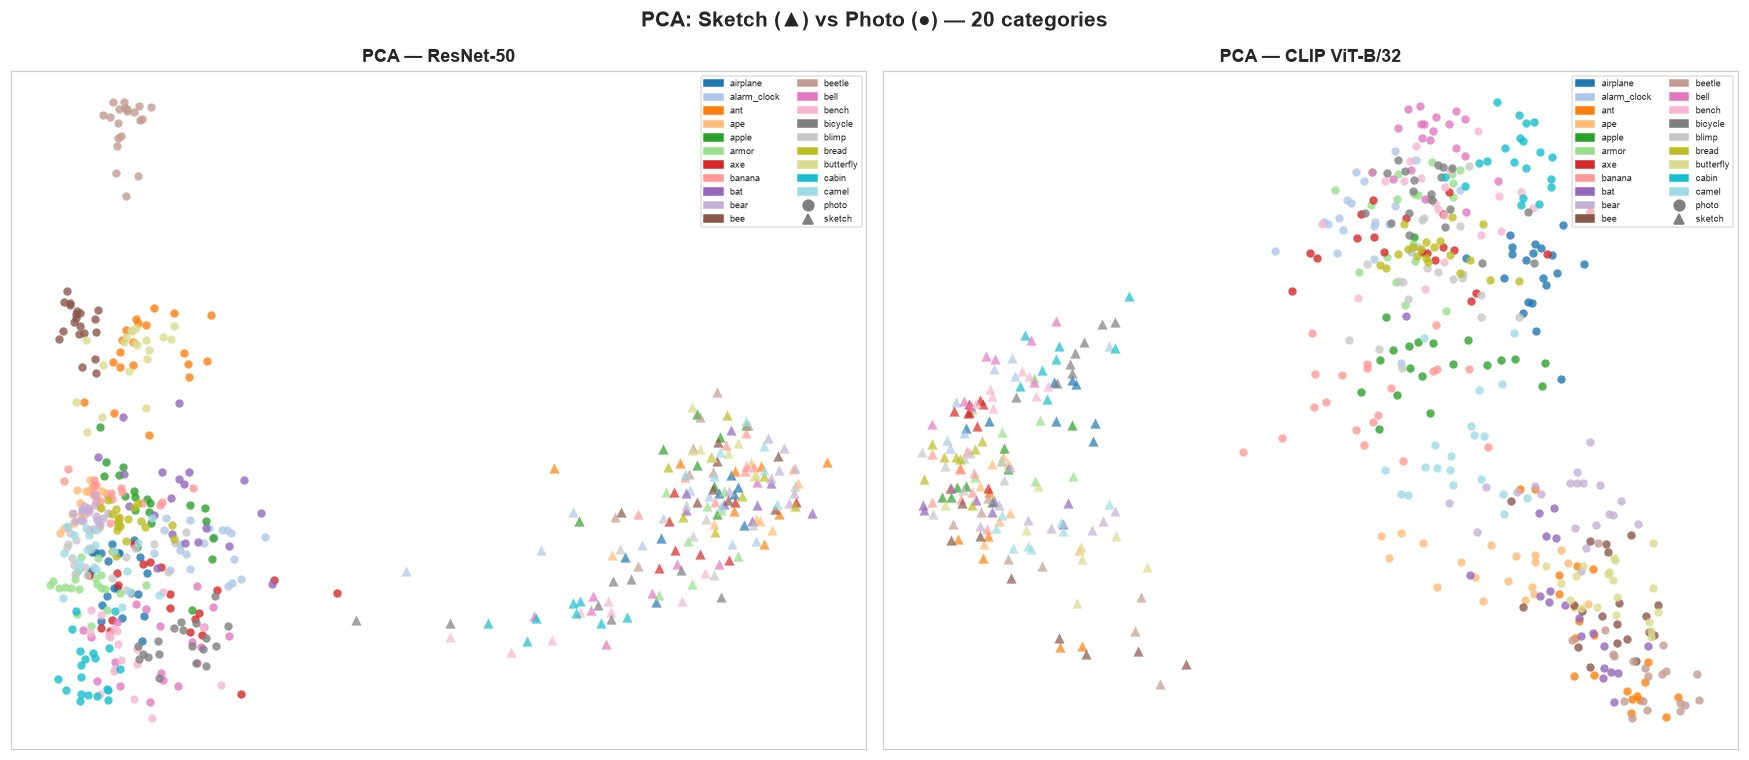

Saved → figs/01_pca_comparison.png


In [9]:
def scatter_2d(p_2d, s_2d, p_cats, s_cats, categories, palette, ax, title):
    cat2col = {c: palette[i] for i, c in enumerate(categories)}
    for cat in categories:
        col = cat2col[cat]
        ax.scatter(p_2d[p_cats==cat, 0], p_2d[p_cats==cat, 1],
                   color=col, marker="o", s=30, alpha=0.8, linewidths=0)
        ax.scatter(s_2d[s_cats==cat, 0], s_2d[s_cats==cat, 1],
                   color=col, marker="^", s=45, alpha=0.7, linewidths=0)
    handles = [mpatches.Patch(color=cat2col[c], label=c) for c in categories]
    ph = plt.Line2D([0],[0], marker="o", color="grey", ls="", label="photo",  ms=7)
    sh = plt.Line2D([0],[0], marker="^", color="grey", ls="", label="sketch", ms=7)
    ax.legend(handles=handles+[ph,sh], fontsize=6, ncol=2,
              loc="upper right", framealpha=0.6)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])


# PCA
def run_pca(p, s):
    combined = np.vstack([p, s])
    proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(combined)
    return proj[:len(p)], proj[len(p):]

p_pca_rn, s_pca_rn = run_pca(p_rn, s_rn)
p_pca_cl, s_pca_cl = run_pca(p_cl, s_cl)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
scatter_2d(p_pca_rn, s_pca_rn, p_cats_rn, s_cats_rn, VIZ_CATEGORY_LIST, PALETTE, axes[0], "PCA — ResNet-50")
scatter_2d(p_pca_cl, s_pca_cl, p_cats_cl, s_cats_cl, VIZ_CATEGORY_LIST, PALETTE, axes[1], "PCA — CLIP ViT-B/32")
fig.suptitle("PCA: Sketch (▲) vs Photo (●) — 20 categories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "01_pca_comparison.png", bbox_inches="tight")
plt.show()
print("Saved → figs/01_pca_comparison.png")

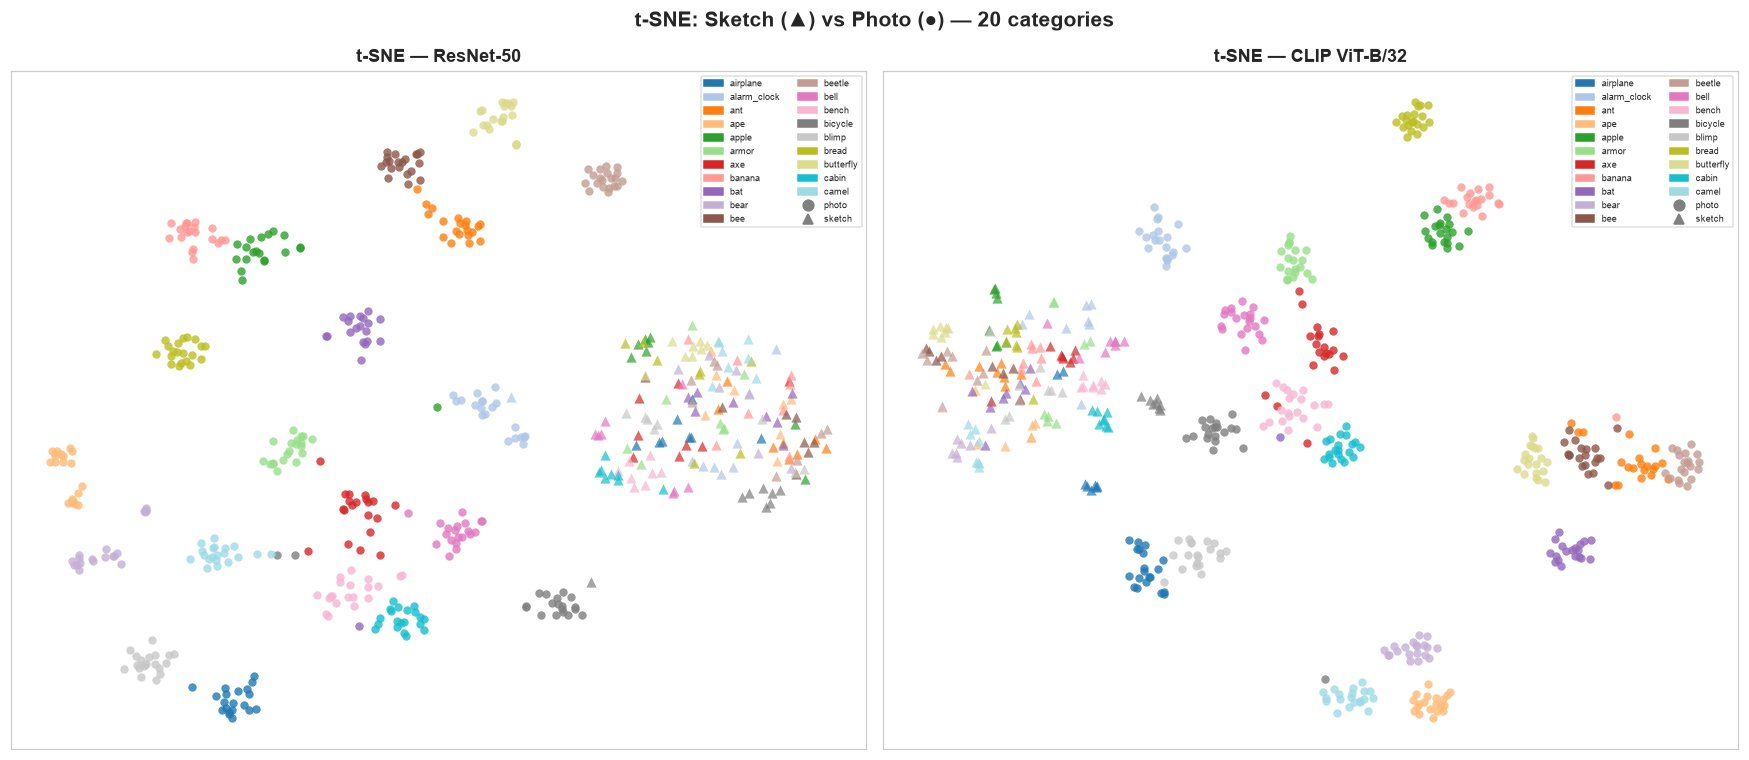

Saved → figs/02_tsne_comparison.png


In [10]:
# t-SNE
def run_tsne(p, s, perplexity=30):
    combined = np.vstack([p, s])
    proj = TSNE(n_components=2, perplexity=perplexity,
                random_state=RANDOM_STATE, max_iter=1000).fit_transform(combined)
    return proj[:len(p)], proj[len(p):]

p_tsne_rn, s_tsne_rn = run_tsne(p_rn, s_rn)
p_tsne_cl, s_tsne_cl = run_tsne(p_cl, s_cl)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
scatter_2d(p_tsne_rn, s_tsne_rn, p_cats_rn, s_cats_rn, VIZ_CATEGORY_LIST, PALETTE, axes[0], "t-SNE — ResNet-50")
scatter_2d(p_tsne_cl, s_tsne_cl, p_cats_cl, s_cats_cl, VIZ_CATEGORY_LIST, PALETTE, axes[1], "t-SNE — CLIP ViT-B/32")
fig.suptitle("t-SNE: Sketch (▲) vs Photo (●) — 20 categories", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "02_tsne_comparison.png", bbox_inches="tight")
plt.show()
print("Saved → figs/02_tsne_comparison.png")

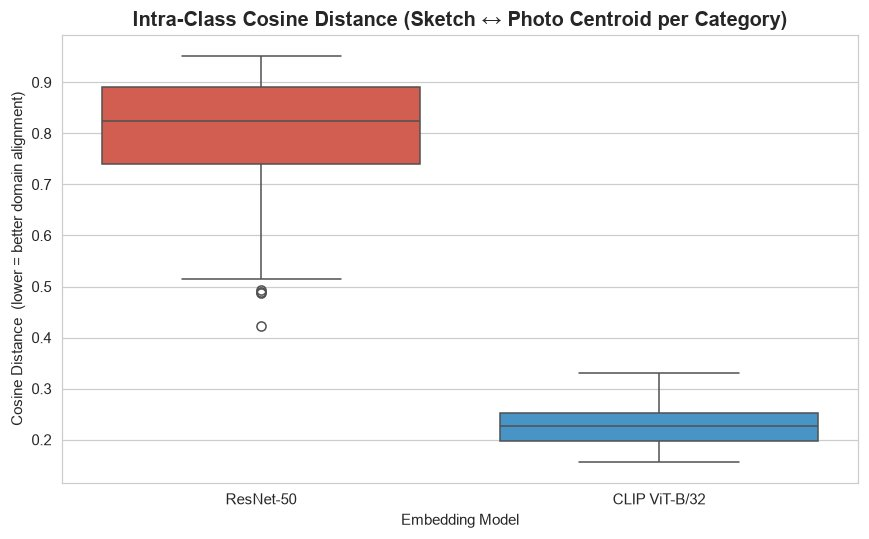

ResNet-50            | mean: 0.7939  median: 0.8238
CLIP ViT-B/32        | mean: 0.2290  median: 0.2273


In [11]:
# Intra-class domain gap: cosine distance between sketch & photo centroids per category
def intra_class_distances(photo_emb, sketch_emb, photo_df, sketch_df, categories):
    p_df = photo_df.reset_index(drop=True)
    s_df = sketch_df.reset_index(drop=True)
    rows = []
    for cat in categories:
        p_idx = p_df.index[p_df["category"] == cat].tolist()
        s_idx = s_df.index[s_df["category"] == cat].tolist()
        pc = photo_emb[p_idx].mean(0);  pc /= np.linalg.norm(pc)
        sc = sketch_emb[s_idx].mean(0); sc /= np.linalg.norm(sc)
        rows.append({"category": cat, "cosine_distance": float(1 - np.dot(pc, sc))})
    return pd.DataFrame(rows)


dist_rn = intra_class_distances(photo_emb_resnet, sketch_emb_resnet, photo_df, eval_sketch_df, CATEGORIES)
dist_cl = intra_class_distances(photo_emb_clip,   sketch_emb_clip,   photo_df, eval_sketch_df, CATEGORIES)
dist_rn["model"] = "ResNet-50";   dist_cl["model"] = "CLIP ViT-B/32"
dist_all = pd.concat([dist_rn, dist_cl], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=dist_all, x="model", y="cosine_distance",
            palette=["#e74c3c", "#3498db"], ax=ax)
ax.set_title("Intra-Class Cosine Distance (Sketch ↔ Photo Centroid per Category)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Embedding Model")
ax.set_ylabel("Cosine Distance  (lower = better domain alignment)")
plt.tight_layout()
plt.savefig(FIGS_DIR / "03_domain_gap_boxplot.png", bbox_inches="tight")
plt.show()

for model in ["ResNet-50", "CLIP ViT-B/32"]:
    d = dist_all[dist_all["model"] == model]["cosine_distance"]
    print(f"{model:20s} | mean: {d.mean():.4f}  median: {d.median():.4f}")

---
## 6. Vector Database - Qdrant Setup & HNSW Indexing

**Qdrant** is a purpose-built vector database that supports Approximate Nearest Neighbour (ANN) search via the **HNSW (Hierarchical Navigable Small World)** algorithm. HNSW builds a multi-layer proximity graph over the embedding space: queries navigate from coarse upper layers down to fine lower layers, finding approximate neighbours in $O(\log N)$ hops.

Key HNSW parameters:
- **`m`** — edges per node in the graph. Higher → better recall, more memory.
- **`ef_construct`** — beam width during index build. Higher → better graph quality, slower build.
- **`ef` (at search time)** — beam width during query. Higher → better recall, higher latency.

In [12]:
client = QdrantClient(":memory:")
print("Qdrant initialised (in-memory mode)")

HNSW_M            = 16
HNSW_EF_CONSTRUCT = 100

COLLECTIONS = {
    "photos_resnet": {"dim": 2048, "emb": photo_emb_resnet},
    "photos_clip"  : {"dim":  512, "emb": photo_emb_clip  },
}

for col_name, cfg in COLLECTIONS.items():
    client.recreate_collection(
        collection_name=col_name,
        vectors_config=VectorParams(size=cfg["dim"], distance=Distance.COSINE),
        hnsw_config=HnswConfigDiff(m=HNSW_M, ef_construct=HNSW_EF_CONSTRUCT)
    )

    UPSERT_BATCH = 512
    emb = cfg["emb"]
    t0  = time.time()

    for start in tqdm(range(0, len(photo_df), UPSERT_BATCH), desc=f"Indexing {col_name}"):
        end   = min(start + UPSERT_BATCH, len(photo_df))
        chunk = photo_df.iloc[start:end].reset_index(drop=False)
        points = [
            PointStruct(
                id=int(start + i),
                vector=emb[start + i].tolist(),
                payload={"category": row["category"], "path": row["path"]}
            )
            for i, row in chunk.iterrows()
        ]
        client.upsert(collection_name=col_name, points=points)

    info = client.get_collection(col_name)
    print(f"  {col_name:20s} | {info.points_count:,} vectors | dim={cfg['dim']} | {time.time()-t0:.1f}s")

print(f"\nHNSW config: m={HNSW_M}, ef_construct={HNSW_EF_CONSTRUCT}, distance=COSINE")

Qdrant initialised (in-memory mode)


Indexing photos_resnet:   0%|          | 0/25 [00:00<?, ?it/s]

  photos_resnet        | 12,500 vectors | dim=2048 | 15.9s


Indexing photos_clip:   0%|          | 0/25 [00:00<?, ?it/s]

  photos_clip          | 12,500 vectors | dim=512 | 6.3s

HNSW config: m=16, ef_construct=100, distance=COSINE


---
## 7. Retrieval Pipeline & Qualitative Inspection

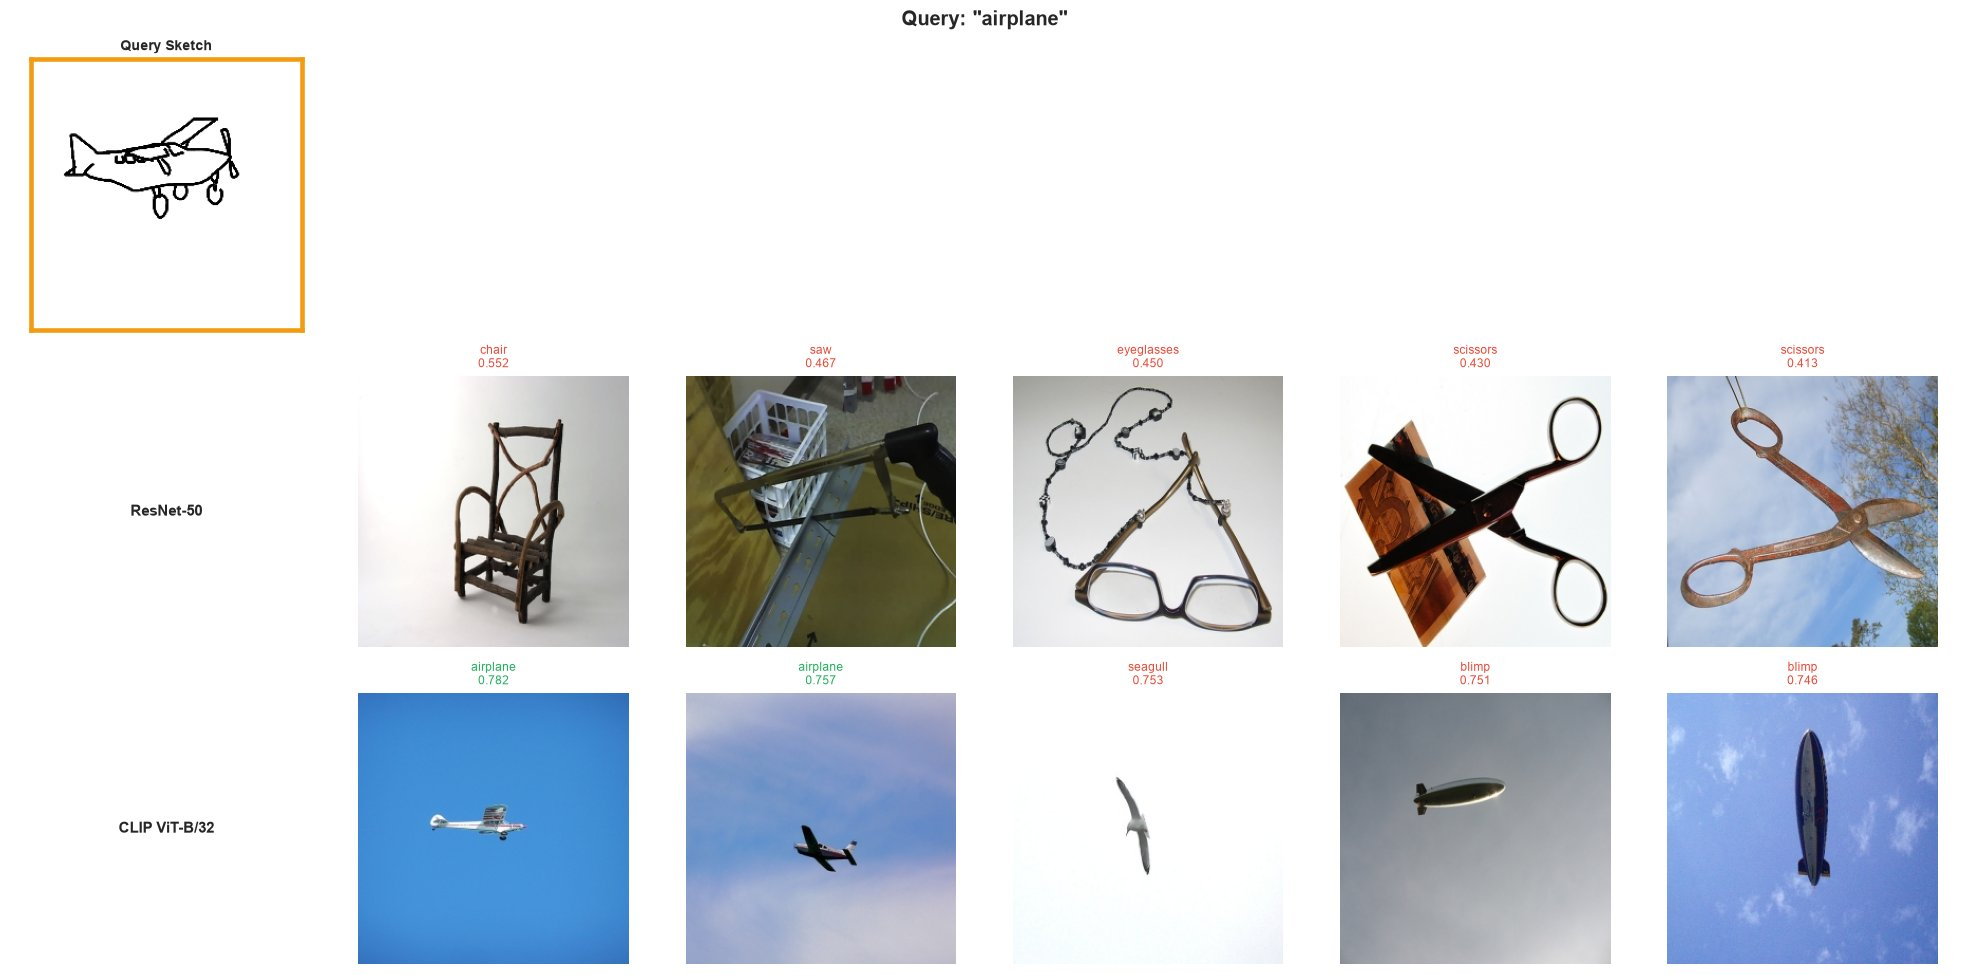

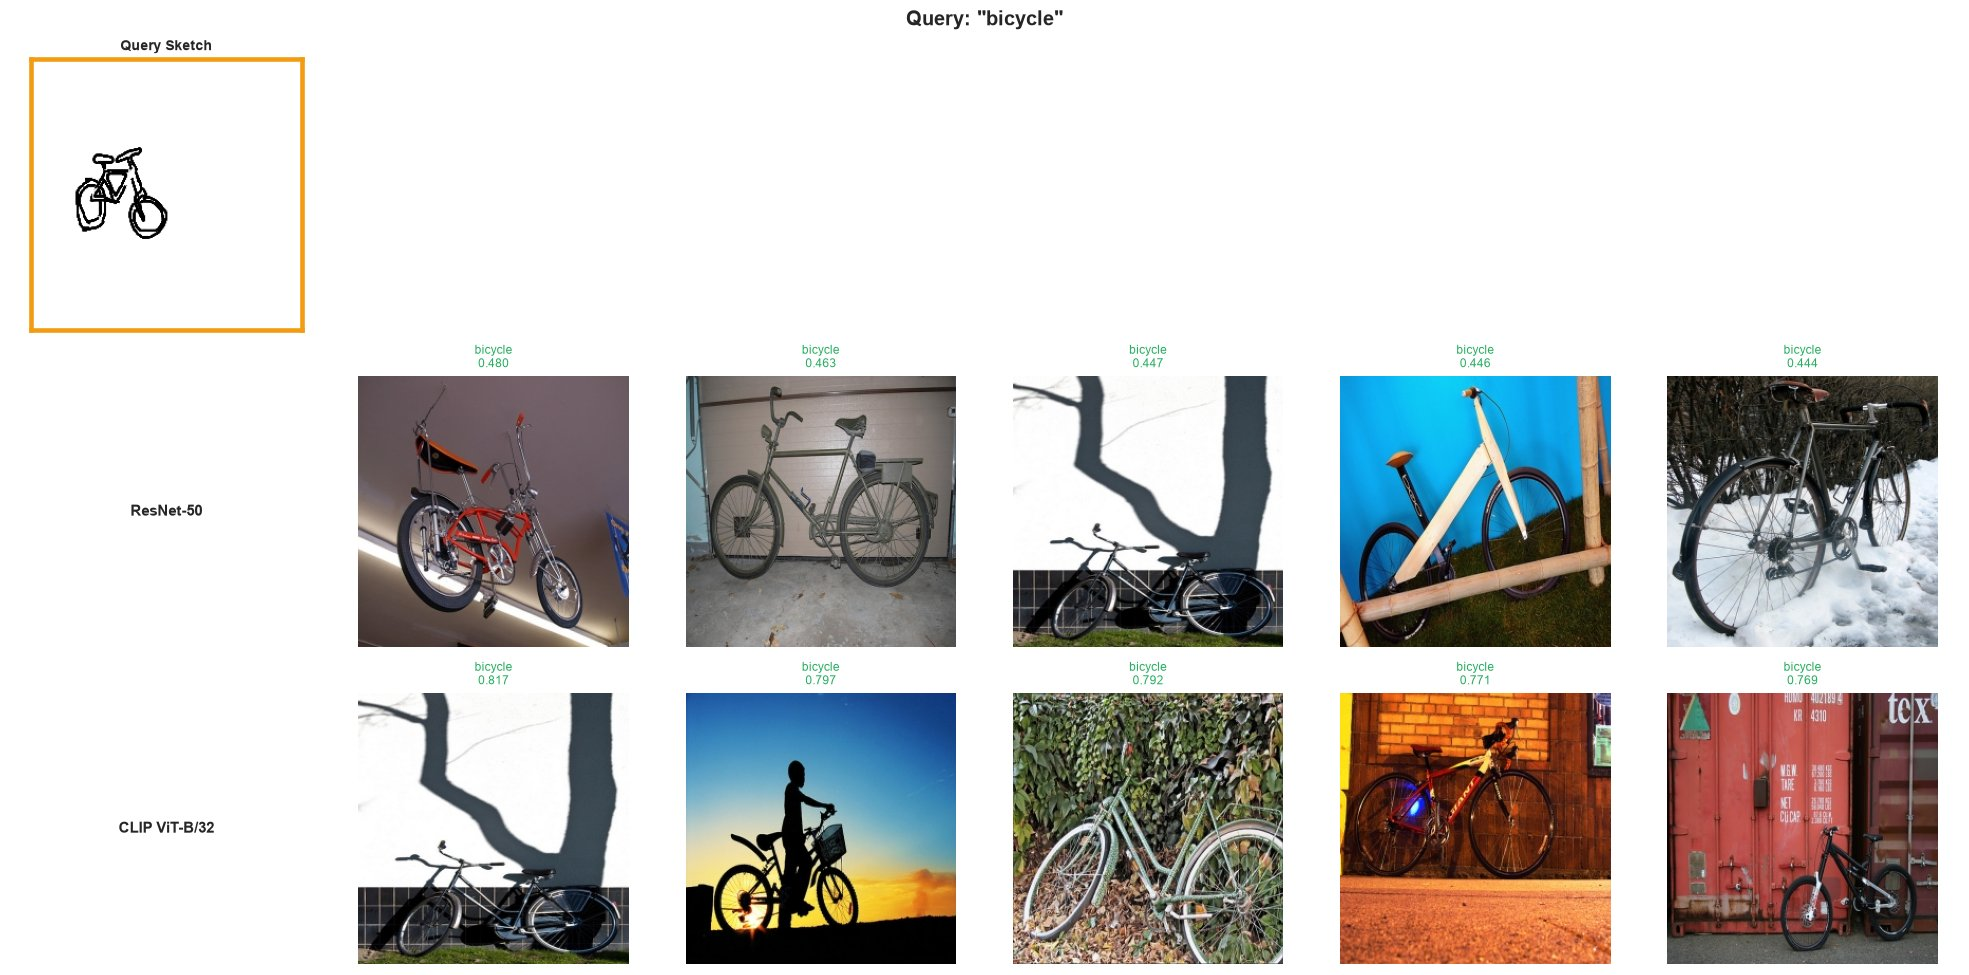

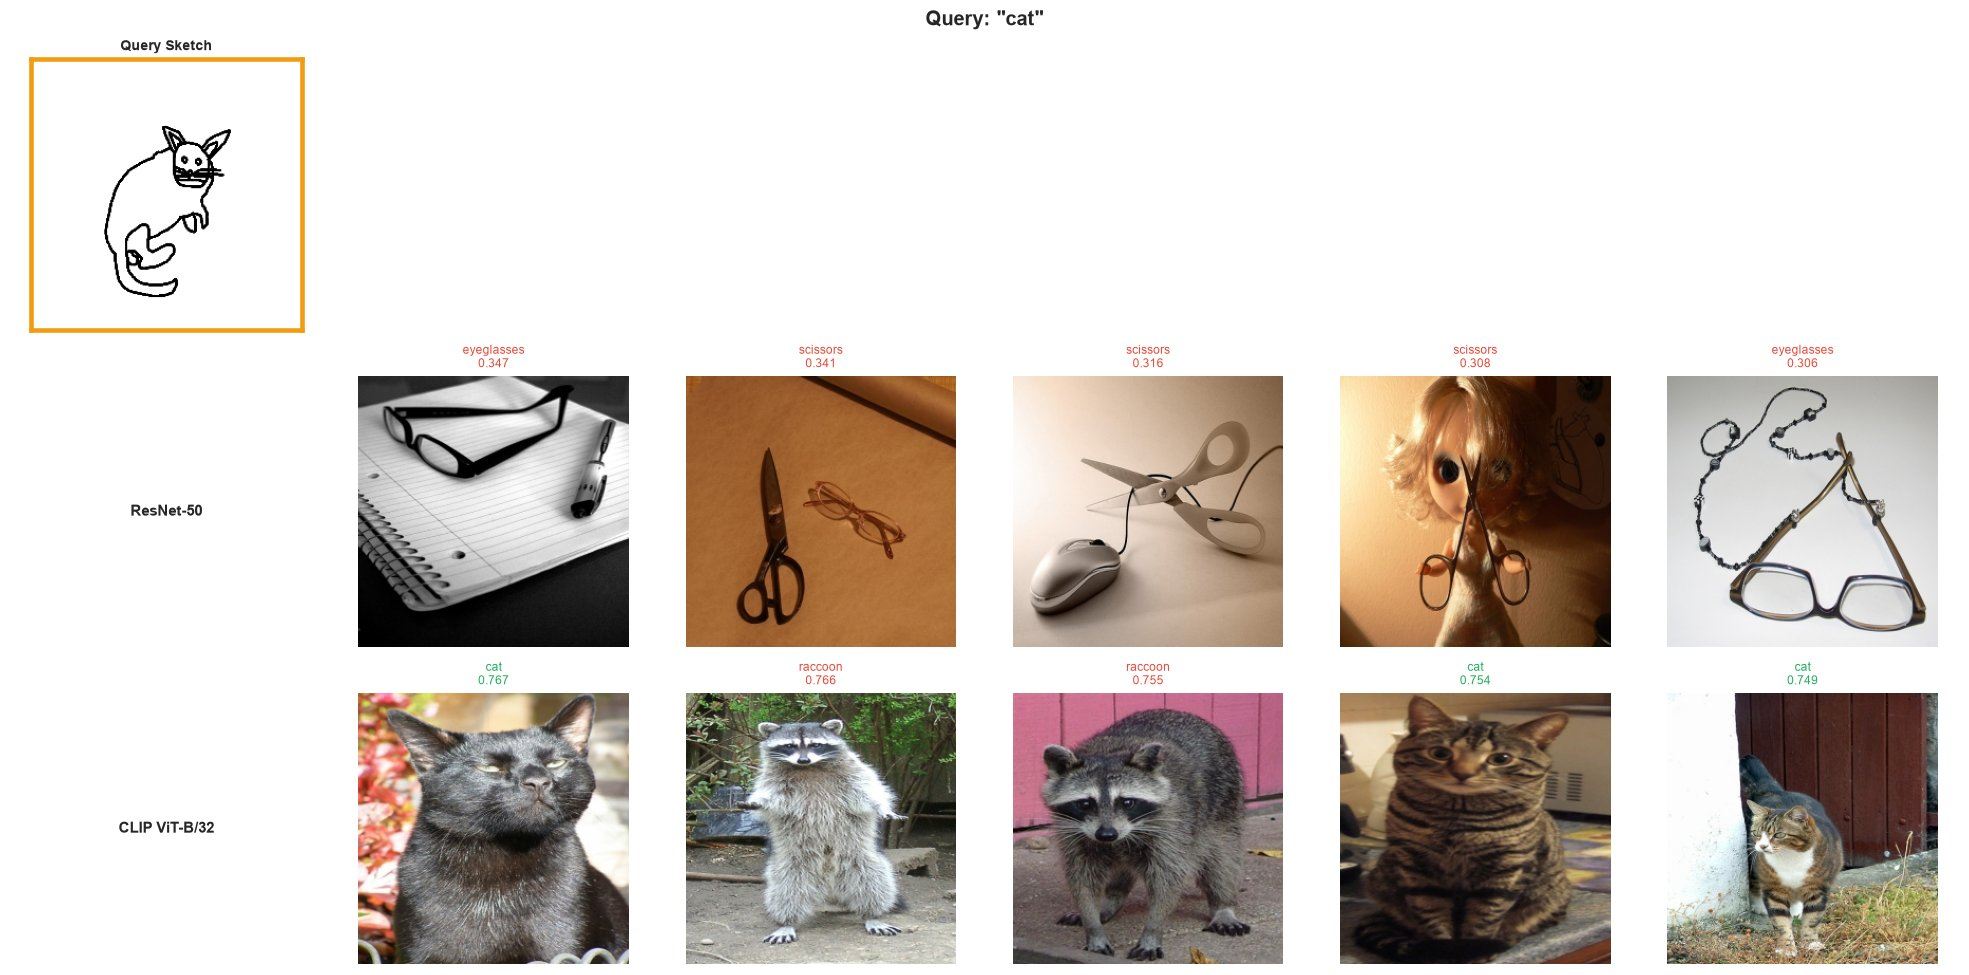

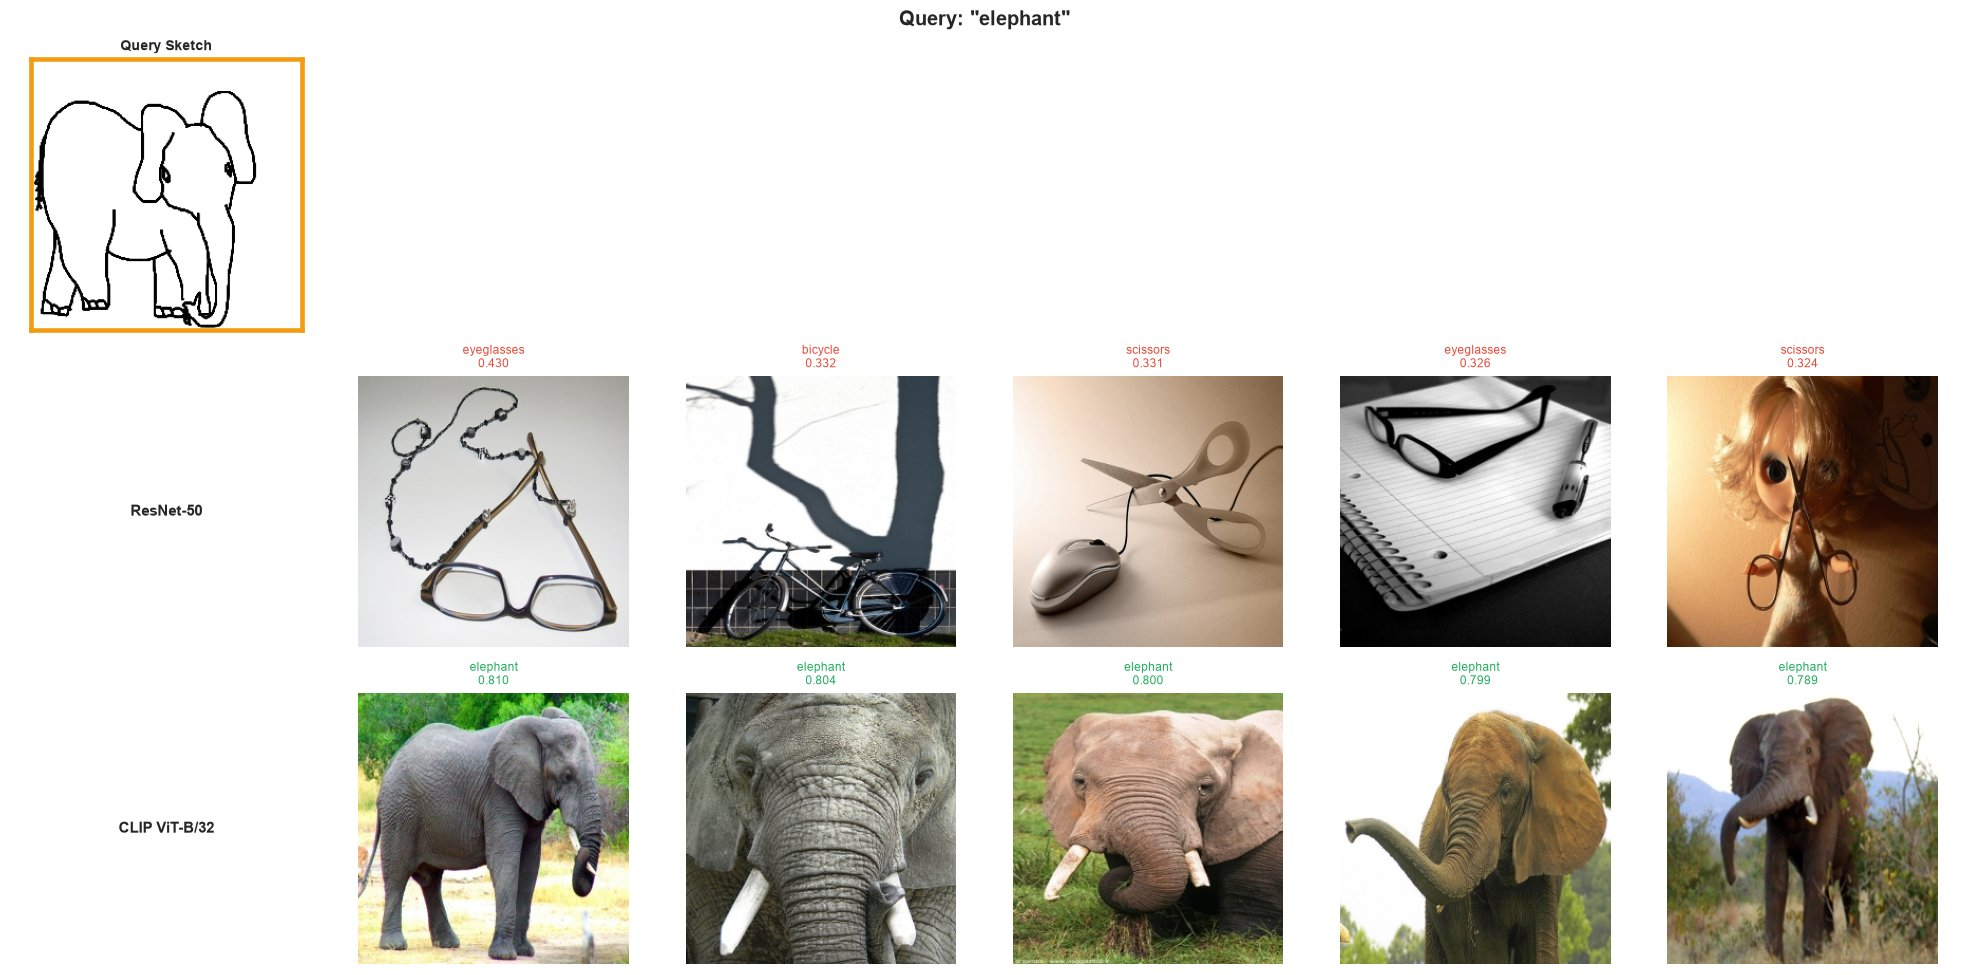

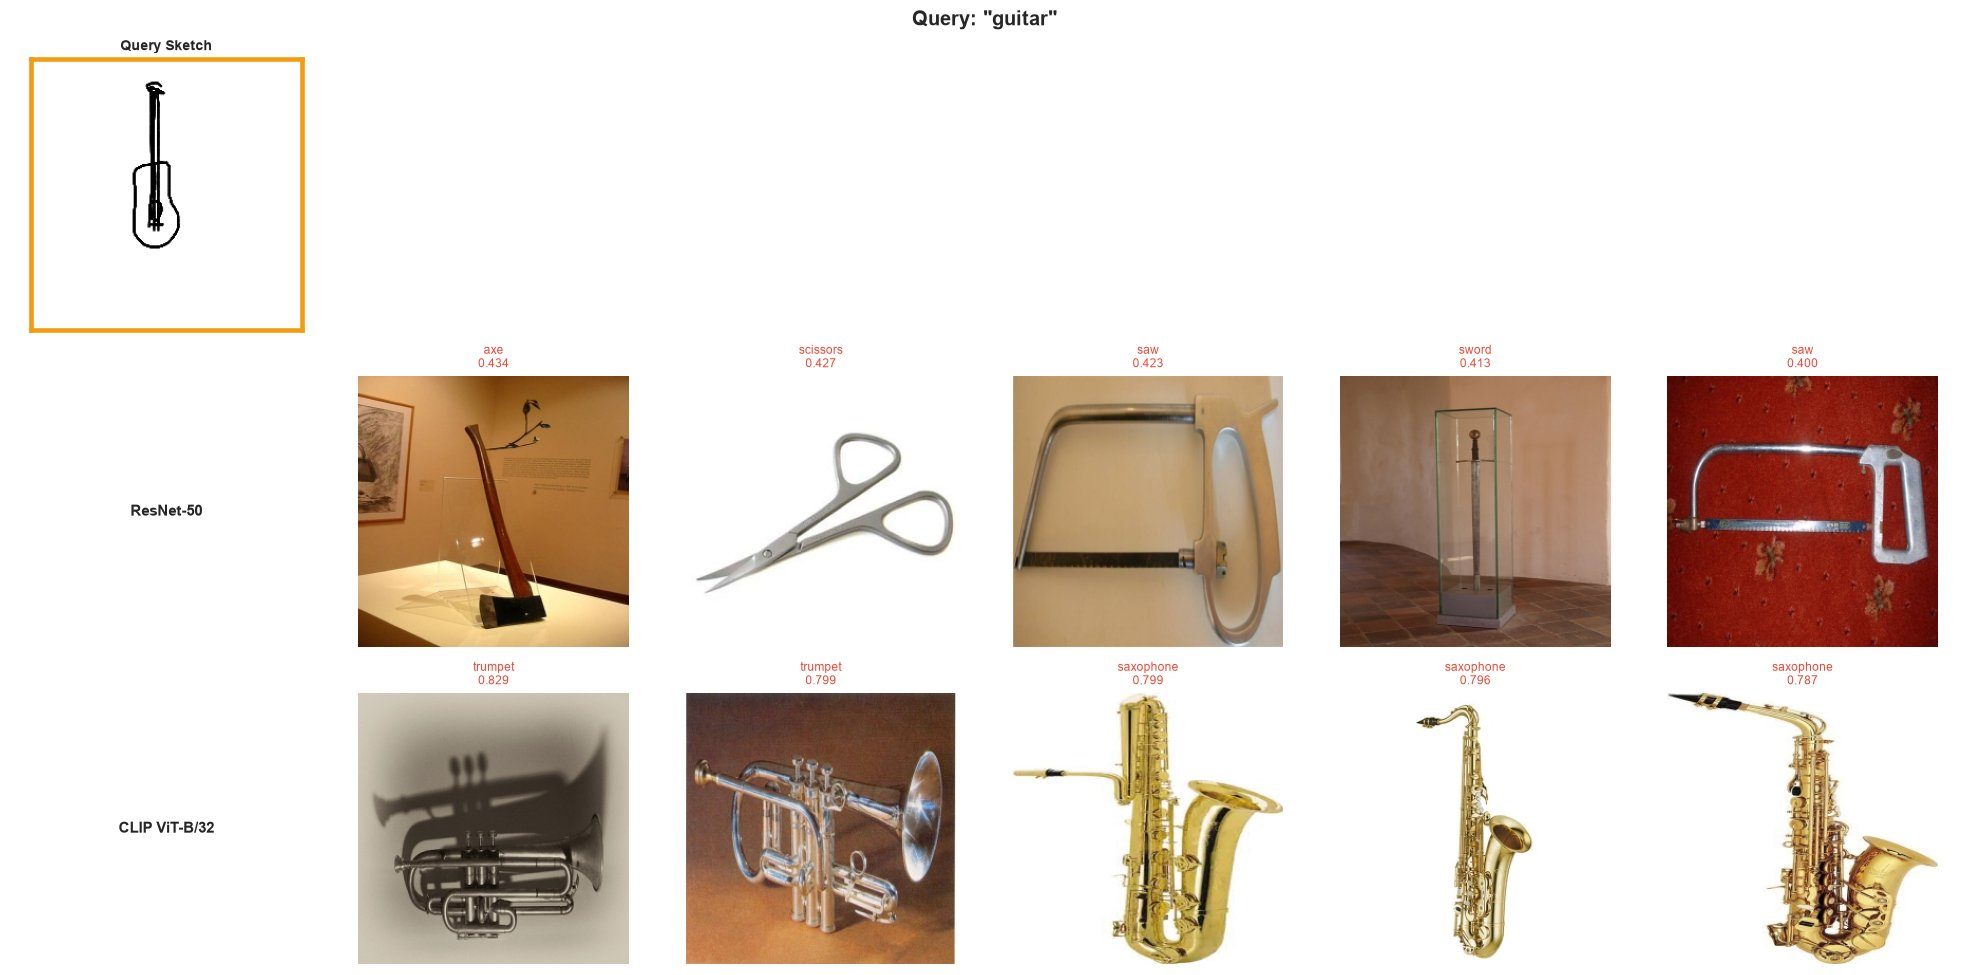

Green border = correct category | Red border = wrong category


In [13]:
def retrieve(collection, query_vec, top_k=10):
    """Query Qdrant; return list of (score, category, path)."""
    hits = client.query_points(
        collection_name=collection,
        query=query_vec.tolist(),
        limit=top_k,
        with_payload=True,
    ).points
    return [(h.score, h.payload["category"], h.payload["path"]) for h in hits]


def show_retrieval_grid(sketch_path, rn_results, cl_results, query_cat, top_k=5):
    fig, axes = plt.subplots(3, top_k + 1, figsize=(3 * (top_k + 1), 9))
    fig.suptitle(f'Query: "{query_cat}"', fontsize=13, fontweight="bold")

    for j in range(top_k + 1): axes[0, j].axis("off")
    axes[0, 0].imshow(Image.open(sketch_path).convert("RGB"))
    axes[0, 0].set_title("Query Sketch", fontsize=9, fontweight="bold")
    axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
    for sp in axes[0, 0].spines.values(): sp.set_edgecolor("#f39c12"); sp.set_linewidth(3)

    for row_i, (results, label) in enumerate(
        [(rn_results, "ResNet-50"), (cl_results, "CLIP ViT-B/32")], start=1
    ):
        axes[row_i, 0].axis("off")
        axes[row_i, 0].text(0.5, 0.5, label, ha="center", va="center",
                             fontsize=10, fontweight="bold",
                             transform=axes[row_i, 0].transAxes)
        for col_j, (score, cat, path) in enumerate(results[:top_k]):
            correct = (cat == query_cat)
            axes[row_i, col_j+1].imshow(Image.open(path))
            axes[row_i, col_j+1].set_title(
                f"{cat}\n{score:.3f}", fontsize=8,
                color="#27ae60" if correct else "#e74c3c"
            )
            axes[row_i, col_j+1].axis("off")
            for sp in axes[row_i, col_j+1].spines.values():
                sp.set_edgecolor("#27ae60" if correct else "#e74c3c")
                sp.set_linewidth(2.5); sp.set_visible(True)
    plt.tight_layout()
    return fig


DEMO_CATS = ["airplane", "bicycle", "cat", "elephant", "guitar"]

for cat in DEMO_CATS:
    row   = eval_sketch_df[eval_sketch_df["category"] == cat].iloc[0]
    s_idx = eval_sketch_df.index[eval_sketch_df["category"] == cat][0]

    rn_res = retrieve("photos_resnet", sketch_emb_resnet[s_idx], top_k=5)
    cl_res = retrieve("photos_clip",   sketch_emb_clip[s_idx],   top_k=5)

    fig = show_retrieval_grid(row["path"], rn_res, cl_res, cat)
    fig.savefig(FIGS_DIR / f"04_retrieval_{cat}.png", bbox_inches="tight")
    plt.show(); plt.close()

print("Green border = correct category | Red border = wrong category")

---
## 8. Evaluation & Benchmarking

1,250 sketches: 10 per category × 125 categories.

**Metrics:**
- **Recall@K** — fraction of queries where at least one correct-category photo appears in the top-K results.
- **MRR (Mean Reciprocal Rank)** — average of $\frac{1}{\text{rank of first correct result}}$; rewards ranking correct results higher.
- **Mean query latency** — average wall-clock time per query in milliseconds.

In [14]:
def evaluate_retrieval(collection, query_embeddings, query_categories,
                        top_k_values=TOP_K_VALUES, model_name=""):
    """
    Full retrieval evaluation over a query set.
    Returns (summary_df, per_query_df).
    """
    max_k = max(top_k_values)
    n_q   = len(query_categories)
    hits  = {k: 0 for k in top_k_values}
    rr_list, latencies, per_query = [], [], []

    for q_vec, q_cat in tqdm(
        zip(query_embeddings, query_categories),
        total=n_q, desc=f"Evaluating {model_name}"
    ):
        t0 = time.perf_counter()
        results = retrieve(collection, q_vec, top_k=max_k)
        latencies.append((time.perf_counter() - t0) * 1000)

        retrieved_cats = [r[1] for r in results]
        for k in top_k_values:
            if q_cat in retrieved_cats[:k]: hits[k] += 1

        rr = next((1.0/(i+1) for i, c in enumerate(retrieved_cats) if c==q_cat), 0.0)
        rr_list.append(rr)
        per_query.append({"query_category": q_cat, "rr": rr,
                           "latency_ms": latencies[-1], "model": model_name})

    row = {f"Recall@{k}": round(hits[k]/n_q, 4) for k in top_k_values}
    row["MRR"]               = round(float(np.mean(rr_list)), 4)
    row["Mean Latency (ms)"] = round(float(np.mean(latencies)), 3)
    row["P95 Latency (ms)"]  = round(float(np.percentile(latencies, 95)), 3)
    row["Model"]             = model_name
    return pd.DataFrame([row]), pd.DataFrame(per_query)


q_cats = eval_sketch_df["category"].tolist()
df_rn, pq_rn = evaluate_retrieval("photos_resnet", sketch_emb_resnet, q_cats, model_name="ResNet-50")
df_cl, pq_cl = evaluate_retrieval("photos_clip",   sketch_emb_clip,   q_cats, model_name="CLIP ViT-B/32")

results_df = pd.concat([df_rn, df_cl], ignore_index=True).set_index("Model")
results_df["Embedding Dim"] = [2048, 512]
print(results_df.T.to_string())

Evaluating ResNet-50:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating CLIP ViT-B/32:   0%|          | 0/1250 [00:00<?, ?it/s]

Model              ResNet-50  CLIP ViT-B/32
Recall@1              0.0656         0.3728
Recall@5              0.1296         0.5376
Recall@10             0.1592         0.6080
Recall@20             0.2152         0.6896
MRR                   0.0957         0.4478
Mean Latency (ms)   102.0630        24.9690
P95 Latency (ms)    118.6790        28.2520
Embedding Dim      2048.0000       512.0000


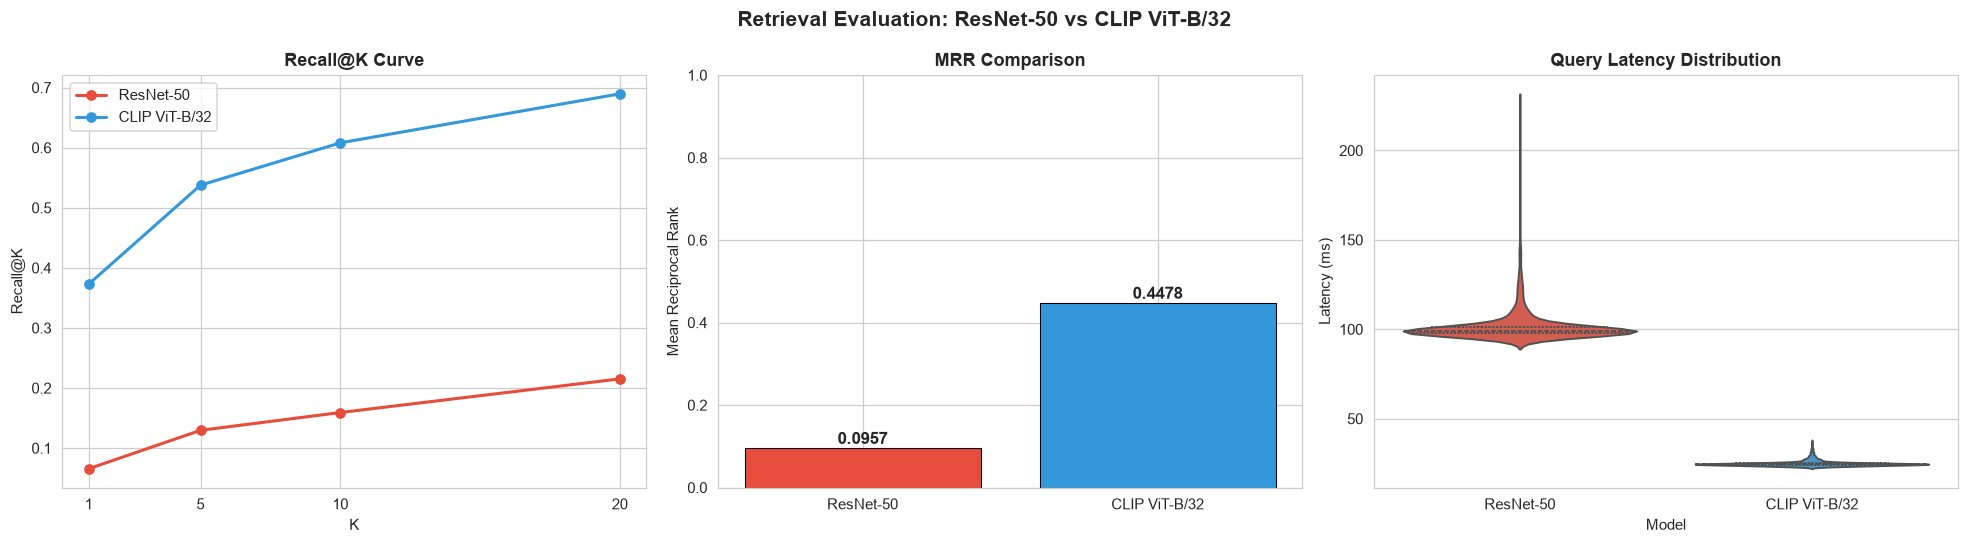

Saved → figs/05_evaluation_summary.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recall@K curve
for model_name, color in [("ResNet-50", "#e74c3c"), ("CLIP ViT-B/32", "#3498db")]:
    row = results_df.loc[model_name]
    axes[0].plot(TOP_K_VALUES, [row[f"Recall@{k}"] for k in TOP_K_VALUES],
                 marker="o", label=model_name, color=color, lw=2)
axes[0].set_xlabel("K"); axes[0].set_ylabel("Recall@K")
axes[0].set_title("Recall@K Curve", fontweight="bold")
axes[0].legend(); axes[0].set_xticks(TOP_K_VALUES)

# MRR bar
mrr_vals = [results_df.loc["ResNet-50", "MRR"], results_df.loc["CLIP ViT-B/32", "MRR"]]
axes[1].bar(["ResNet-50", "CLIP ViT-B/32"], mrr_vals,
            color=["#e74c3c", "#3498db"], edgecolor="black", lw=0.7)
axes[1].set_ylabel("Mean Reciprocal Rank"); axes[1].set_ylim(0, 1)
axes[1].set_title("MRR Comparison", fontweight="bold")
for i, v in enumerate(mrr_vals):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

# Latency violin
pq_all = pd.concat([pq_rn, pq_cl], ignore_index=True)
sns.violinplot(data=pq_all, x="model", y="latency_ms",
               palette=["#e74c3c", "#3498db"], ax=axes[2], inner="quartile")
axes[2].set_title("Query Latency Distribution", fontweight="bold")
axes[2].set_ylabel("Latency (ms)"); axes[2].set_xlabel("Model")

plt.suptitle("Retrieval Evaluation: ResNet-50 vs CLIP ViT-B/32", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "05_evaluation_summary.png", bbox_inches="tight")
plt.show()
print("Saved → figs/05_evaluation_summary.png")

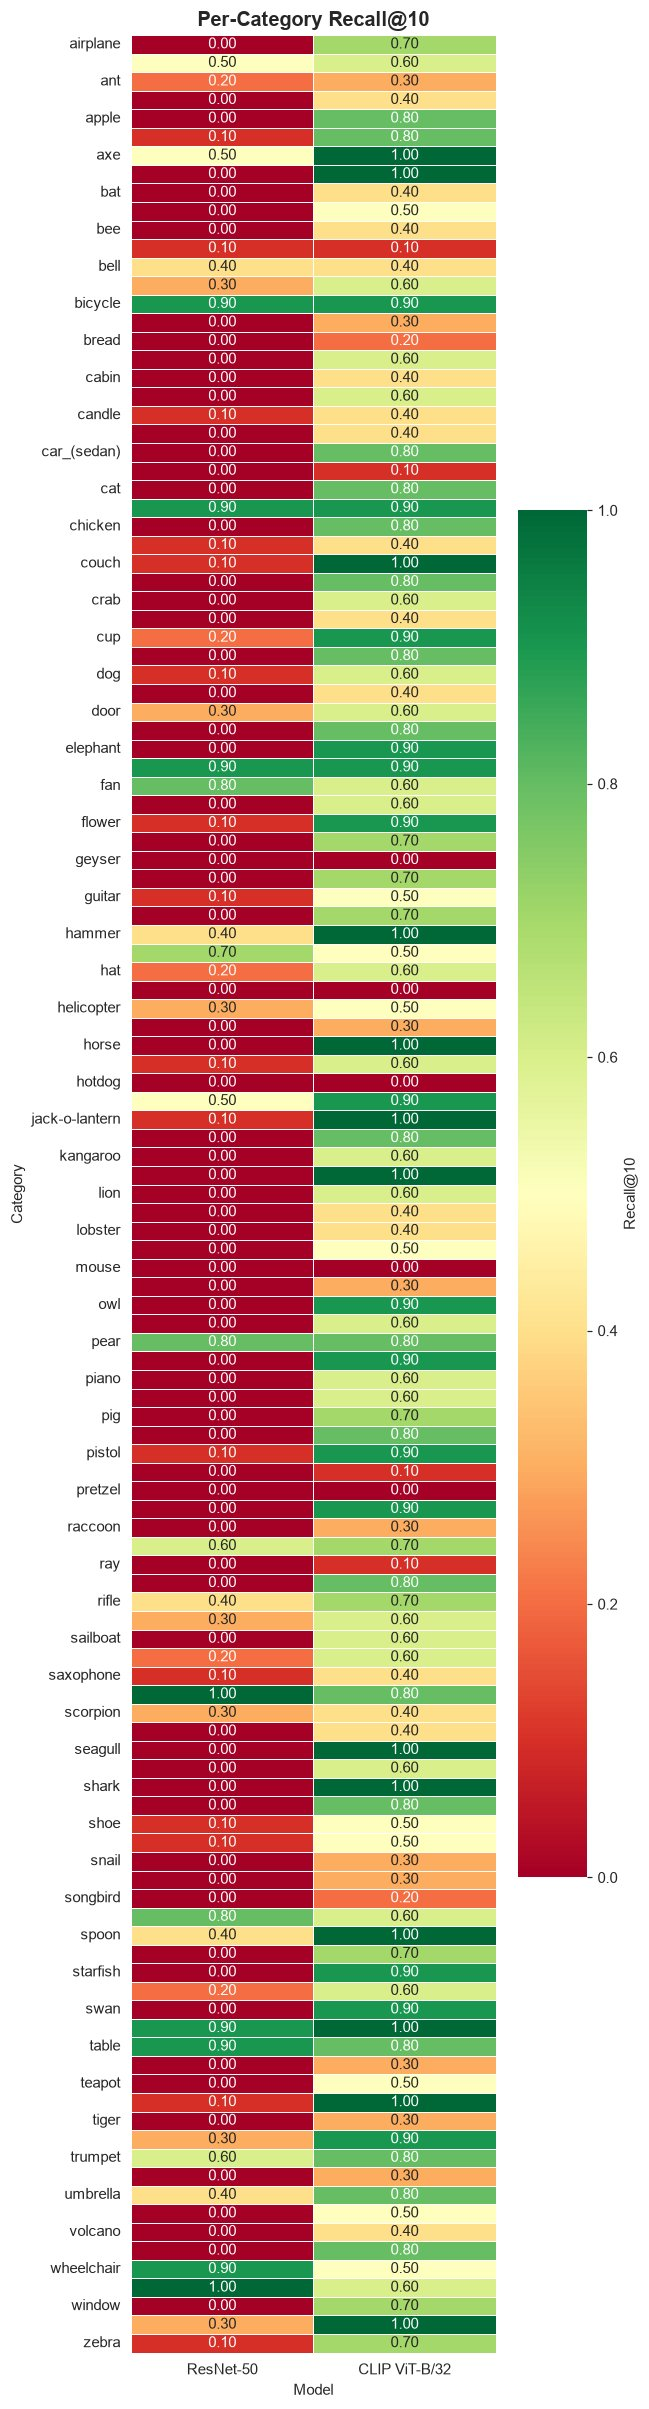

Saved → figs/06_category_heatmap.png


In [16]:
# Per-category Recall@10 heatmap
def per_cat_recall_at_k(pq_df, k):
    """Recall@K per category derived from per-query MRR data."""
    pq_df = pq_df.copy()
    pq_df["hit"] = pq_df["rr"] >= (1.0 / k)
    return pq_df.groupby("query_category")["hit"].mean()

heatmap_df = pd.DataFrame({
    "ResNet-50"    : per_cat_recall_at_k(pq_rn, 10),
    "CLIP ViT-B/32": per_cat_recall_at_k(pq_cl, 10),
}).sort_index()

fig, ax = plt.subplots(figsize=(6, 22))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.4, ax=ax, vmin=0, vmax=1,
            cbar_kws={"label": "Recall@10"})
ax.set_title("Per-Category Recall@10", fontsize=13, fontweight="bold")
ax.set_xlabel("Model"); ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig(FIGS_DIR / "06_category_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → figs/06_category_heatmap.png")

 ef  Recall@10  Mean Lat (ms)
 10      0.645         25.230
 25      0.645         23.827
 50      0.645         25.433
100      0.645         24.944
200      0.645         24.056


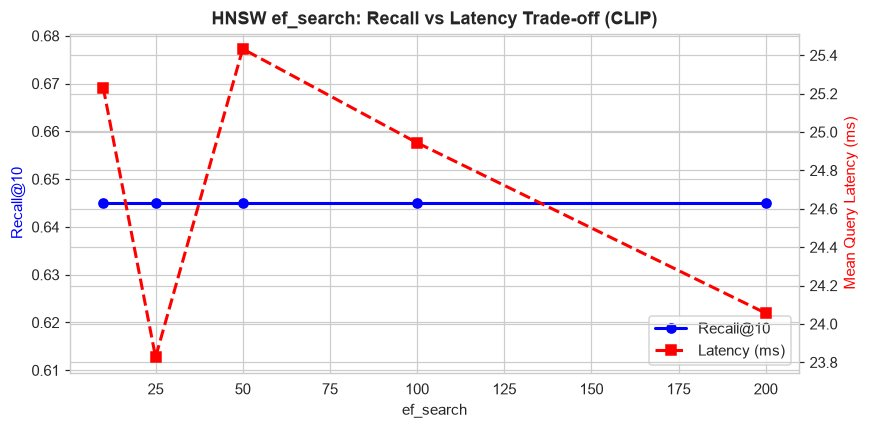

Saved → figs/07_ef_search_tradeoff.png


In [17]:
# HNSW ef_search sensitivity: recall–latency trade-off (CLIP collection)
EF_VALUES   = [10, 25, 50, 100, 200]
SAMPLE_SIZE = 200
sample_idx  = np.random.choice(len(q_cats), size=SAMPLE_SIZE, replace=False)
sample_vecs = sketch_emb_clip[sample_idx]
sample_cats = [q_cats[i] for i in sample_idx]

ef_rows = []
for ef in EF_VALUES:
    hits, lats = 0, []
    for q_vec, q_cat in zip(sample_vecs, sample_cats):
        t0 = time.perf_counter()
        hits_list = client.query_points(
            collection_name="photos_clip",
            query=q_vec.tolist(), limit=10,
            search_params=SearchParams(hnsw_ef=ef, exact=False),
            with_payload=True
        ).points
        lats.append((time.perf_counter()-t0)*1000)
        if any(h.payload["category"]==q_cat for h in hits_list): hits+=1
    ef_rows.append({"ef": ef, "Recall@10": hits/SAMPLE_SIZE, "Mean Lat (ms)": round(np.mean(lats),3)})

ef_df = pd.DataFrame(ef_rows)
print(ef_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(ef_df["ef"], ef_df["Recall@10"],   "b-o", lw=2, label="Recall@10")
ax2.plot(ef_df["ef"], ef_df["Mean Lat (ms)"],"r--s", lw=2, label="Latency (ms)")
ax1.set_xlabel("ef_search"); ax1.set_ylabel("Recall@10", color="b")
ax2.set_ylabel("Mean Query Latency (ms)", color="r")
ax1.set_title("HNSW ef_search: Recall vs Latency Trade-off (CLIP)", fontweight="bold")
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc="lower right")
plt.tight_layout()
plt.savefig(FIGS_DIR / "07_ef_search_tradeoff.png", bbox_inches="tight")
plt.show()
print("Saved → figs/07_ef_search_tradeoff.png")

---
## 9. Live Demo

In [18]:
def preprocess_arbitrary_sketch(image_path):
    """Load any image, embed with both models, return (resnet_vec, clip_vec)."""
    img = Image.open(image_path).convert("RGB")

    # ResNet
    rn_t = resnet_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        rn_v = resnet_model(rn_t).squeeze().cpu().float().numpy()
    rn_v /= np.linalg.norm(rn_v)

    # CLIP
    cl_t = clip_preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        cl_v = clip_model.encode_image(cl_t).squeeze().cpu().float().numpy()
    cl_v /= np.linalg.norm(cl_v)

    return rn_v, cl_v


def live_demo(image_path, top_k=5):
    """End-to-end: load sketch → embed → retrieve → display."""
    print(f"Query: {image_path}")
    rn_v, cl_v = preprocess_arbitrary_sketch(image_path)

    t0 = time.perf_counter(); rn_res = retrieve("photos_resnet", rn_v, top_k)
    rn_lat = (time.perf_counter()-t0)*1000
    t0 = time.perf_counter(); cl_res = retrieve("photos_clip",   cl_v, top_k)
    cl_lat = (time.perf_counter()-t0)*1000

    print(f"ResNet latency: {rn_lat:.2f} ms  |  CLIP latency: {cl_lat:.2f} ms")

    fig, axes = plt.subplots(3, top_k+1, figsize=(3.2*(top_k+1), 10))
    fig.suptitle("Live Demo — Sketch-to-Photo Retrieval", fontsize=14, fontweight="bold")

    for j in range(top_k+1): axes[0,j].axis("off")
    axes[0,0].imshow(Image.open(image_path).convert("RGB"))
    axes[0,0].set_title("Your Sketch", fontsize=11, fontweight="bold")
    axes[0,0].axis("on"); axes[0,0].set_xticks([]); axes[0,0].set_yticks([])
    for sp in axes[0,0].spines.values(): sp.set_edgecolor("#f39c12"); sp.set_linewidth(4)

    for row_i, (results, label) in enumerate([
        (rn_res, f"ResNet-50\n({rn_lat:.1f} ms)"),
        (cl_res, f"CLIP ViT-B/32\n({cl_lat:.1f} ms)"),
    ], start=1):
        axes[row_i,0].axis("off")
        axes[row_i,0].text(0.5, 0.5, label, ha="center", va="center",
                            fontsize=10, fontweight="bold",
                            transform=axes[row_i,0].transAxes)
        for col_j, (score, cat, path) in enumerate(results[:top_k]):
            axes[row_i, col_j+1].imshow(Image.open(path))
            axes[row_i, col_j+1].set_title(f"{cat}\n{score:.3f}", fontsize=9)
            axes[row_i, col_j+1].axis("off")

    plt.tight_layout()
    plt.savefig(FIGS_DIR / "08_live_demo_result.png", bbox_inches="tight")
    plt.show()
    print("Saved → figs/08_live_demo_result.png")


Query: my_sketch.png
ResNet latency: 106.08 ms  |  CLIP latency: 35.68 ms


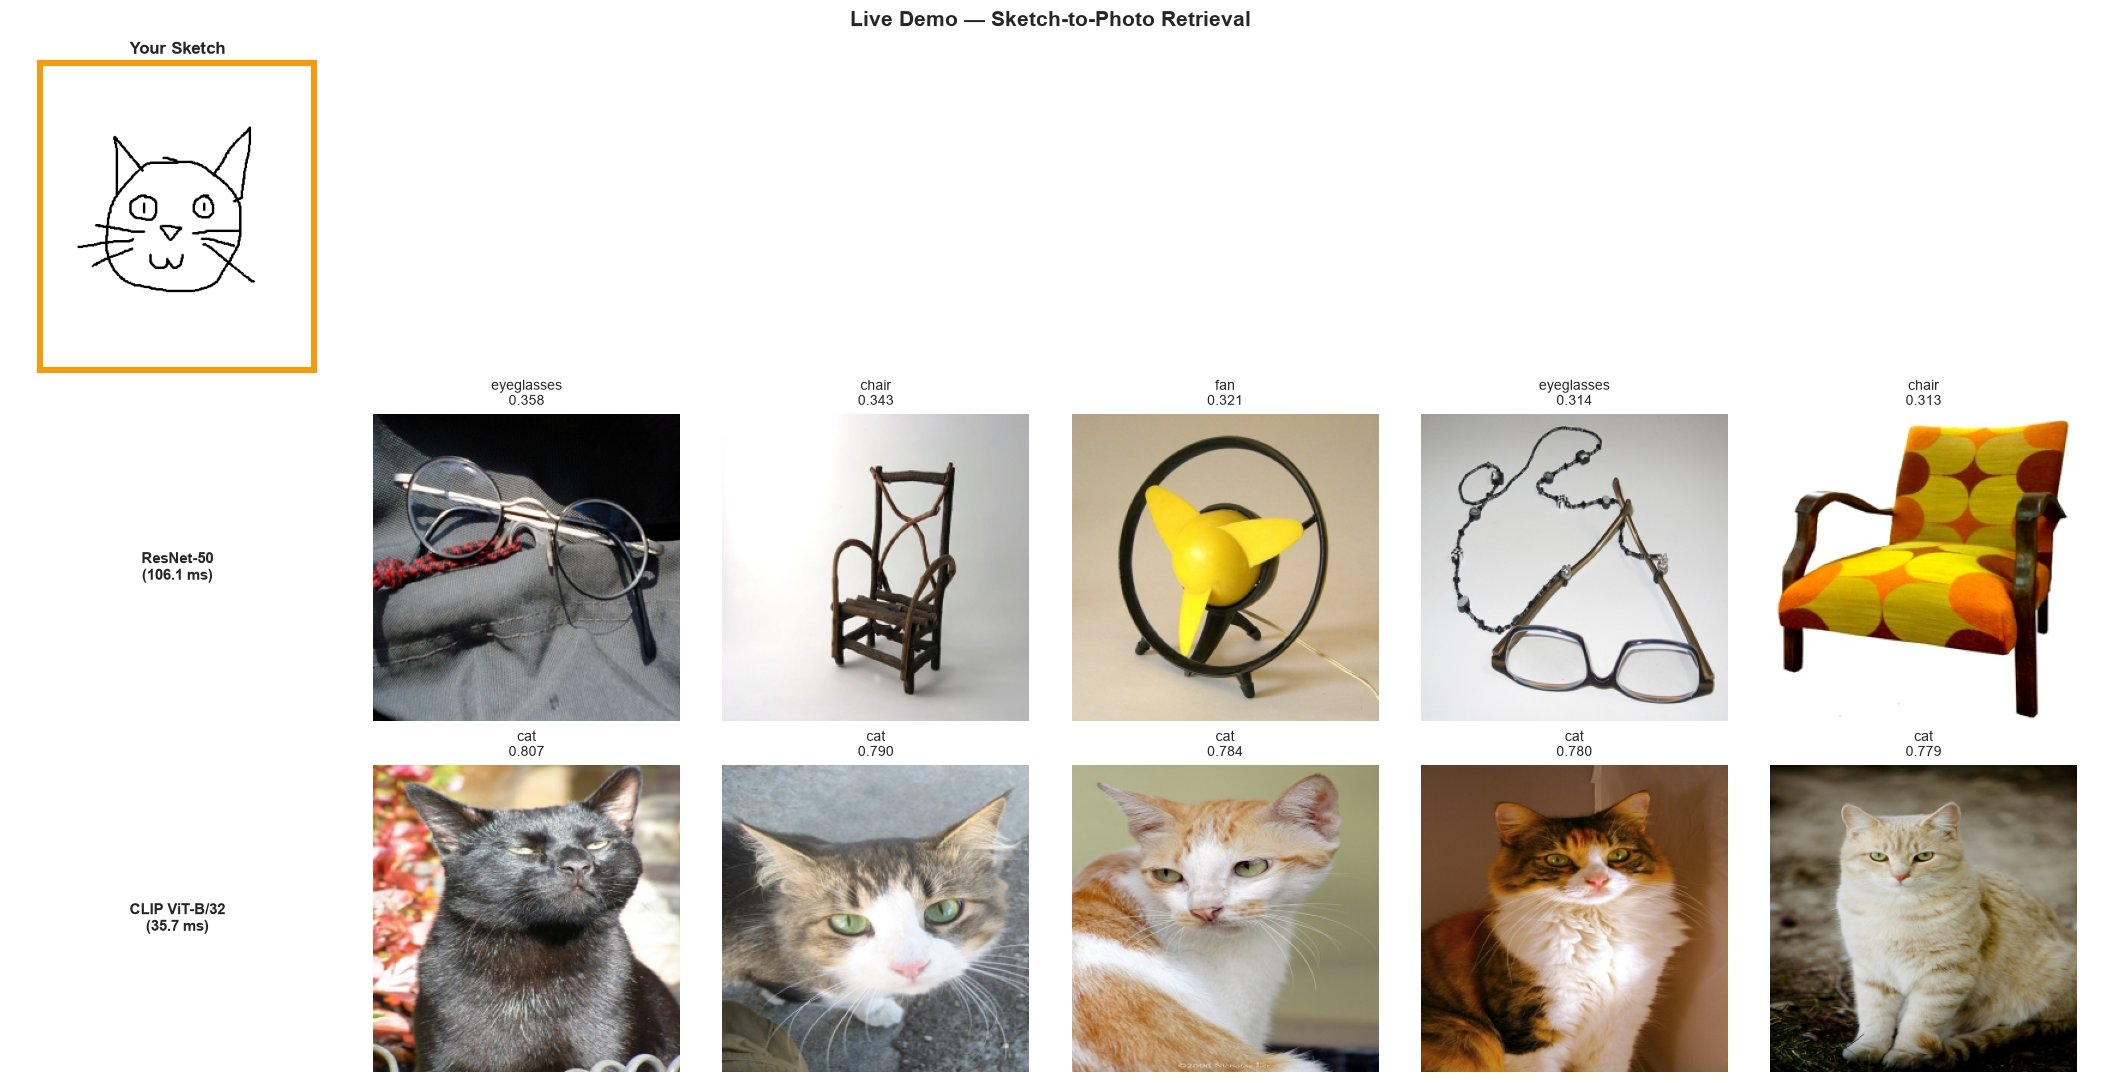

Saved → figs/08_live_demo_result.png


In [25]:
DEMO_SKETCH_PATH = "my_sketch.png"

if Path(DEMO_SKETCH_PATH).exists():
    live_demo(DEMO_SKETCH_PATH, top_k=5)
else:
    print(f"[Demo] Sketch not found at '{DEMO_SKETCH_PATH}'.")
    print("[Demo] Running fallback with a random eval sketch instead...")
    fallback = eval_sketch_df.sample(1, random_state=RANDOM_STATE).iloc[0]
    print(f"[Demo] Category: {fallback['category']}")
    live_demo(fallback["path"], top_k=5)